## Анализ retention игроков, результатов A/B-тестирования игровых акций и определение продуктовых метрик для мобильной игры.
Представьте, что вы работаете в компании, которая разрабатывает мобильные игры. К вам пришел менеджер с рядом задач по исследованию нескольких аспектов мобильного приложения:

В первую очередь, его интересует показатель retention. Напишите функцию для его подсчета.
Помимо этого, в компании провели A/B тестирование наборов акционных предложений. На основе имеющихся данных определите, какой набор можно считать лучшим и на основе каких метрик стоит принять правильное решение.
Предложите метрики для оценки результатов последнего прошедшего тематического события в игре.

### Задание 1
Retention – один из самых важных показателей в компании. Ваша задача – написать функцию, которая будет считать retention игроков (по дням от даты регистрации игрока). Данные лежат в папке shared и имеют следующую структуру:
- shared/problem1-reg_data.csv – данные о времени регистрации
- shared/problem1-auth_data.csv – данные о времени захода пользователей в игру

Функция должна быть написана на python. В ходе решения можно тестировать работу функции как на полном датасете, так и на части (сэмпле) данных.

In [73]:
# Импортируем необходимые библиотеки для выполнения всего проекта
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import pingouin as pg
import scipy.stats as st

In [74]:
# Создаем датафреймы
reg_data = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-nikolaj-sofinskij-pwt6989/shared/problem1-reg_data.csv', sep=';')
auth_data = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-nikolaj-sofinskij-pwt6989/shared/problem1-auth_data.csv', sep=';')

Проведем предварительный анализ данных.

In [75]:
# Посмотрим на датафрейм reg_data
reg_data.head()

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


In [76]:
# Посмотрим на датафрейм auth_data
auth_data.head()

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


In [77]:
# Узнаем количество строк и столбцов в датафреймах
print(f'reg_data:  {reg_data.shape}')
print(f'auth_data: {auth_data.shape}')

reg_data:  (1000000, 2)
auth_data: (9601013, 2)


In [78]:
# Проверим типы данных в столбцах датафреймов
# reg_data
reg_data.dtypes

reg_ts    int64
uid       int64
dtype: object

In [79]:
# auth_data
auth_data.dtypes

auth_ts    int64
uid        int64
dtype: object

In [80]:
# Проверим, есть ли в датафреймах пропущенные значения
# reg_data
reg_data.isna().sum()

reg_ts    0
uid       0
dtype: int64

In [81]:
# auth_data
auth_data.isna().sum()

auth_ts    0
uid        0
dtype: int64

In [82]:
# Проверим, как часто встречается каждое уникальное значение в столбце uid
# reg_data
reg_data['uid'].value_counts()

1110580    1
1110582    1
1110583    1
1110584    1
1110585    1
          ..
4          1
5          1
6          1
7          1
8          1
Name: uid, Length: 1000000, dtype: int64

In [83]:
# auth_data
auth_data['uid'].value_counts()

2         1929
108       1397
158       1367
176       1331
191       1296
          ... 
158613       1
534808       1
534809       1
534810       1
158627       1
Name: uid, Length: 1000000, dtype: int64

In [84]:
# Проверим, что все id пользователей из датафрейма reg_data есть в датафрейме auth_data
print(reg_data['uid'].isin(auth_data['uid']).all())

True


В датафрейме с данными о времени регистрации (reg_data) находится информация о регистрации 1 млн пользователей, пропущенных значений нет.

В датафрейме с данными о времени захода пользователей (auth_data) в игру находится информация о 9 601 013 заходах пользователей в игру, количество уникальных id пользователей составляет 1 млн, пропущенных значений нет.

Все id пользователей из датафрейма reg_data есть в датафрейме auth_data.

Время в обоих датафреймах представлено как Unix timestamp (временная метка) — количество секунд, прошедших с 1 января 1970 года.

In [85]:
# Поменяем в датафреймах тип данных в колонках с временем на datetime
reg_data['reg_ts'] = pd.to_datetime(reg_data['reg_ts'], unit='s')
auth_data['auth_ts'] = pd.to_datetime(auth_data['auth_ts'], unit='s')

In [86]:
# Узнаем период времени, за который у нас есть данные для каждого датафрейма
print(f'reg_data    min: {reg_data.reg_ts.min()}   max: {reg_data.reg_ts.max()}')
print(f'auth_data   min: {auth_data.auth_ts.min()}   max: {auth_data.auth_ts.max()}')

reg_data    min: 1998-11-18 09:43:43   max: 2020-09-23 15:17:24
auth_data   min: 1998-11-18 09:43:43   max: 2020-09-23 15:17:24


Объявим функцию calculate_retention, которая принимает параметры:
- reg_path - абсолютный путь до CSV-файла с данными о времени регистрации (тип данных str)
- auth_path - абсолютный путь до CSV-файла с данными о времени захода пользователей в игру (тип данных str)
- start_date - начальная дата анализируемого периода (включительно) (тип данных str или datetime)
- end_date - конечная дата анализируемого периода (включительно) (тип данных str или datetime)

In [87]:
def calculate_retention(reg_path, auth_path, start_date, end_date):
    
    # Создаем датафрейм с данными о времени регистрации
    reg_data = pd.read_csv(reg_path, sep=';') 
    
    # Создаем датафрейм с данными о времени захода пользователей в игру
    auth_data = pd.read_csv(auth_path, sep=';')
    
    # Меняем тип данных start_date с str на date
    start_date = pd.to_datetime(start_date).date()
    
    # Меняем тип данных end_date с str на date
    end_date = pd.to_datetime(end_date).date()
    
    # В датафрейме reg_data меняем тип данных колонки со временем (reg_ts) с Unix timestamp на date
    reg_data['reg_ts'] = pd.to_datetime(reg_data['reg_ts'], unit='s').dt.date
    
    # В датафрейме auth_data меняем тип данных колонки со временем (auth_ts) с Unix timestamp на date
    auth_data['auth_ts'] = pd.to_datetime(auth_data['auth_ts'], unit='s').dt.date
    
    # Оставляем в датафрейме reg_data только данные за необходимый период
    reg_data = reg_data.query('reg_ts >= @start_date and reg_ts <= @end_date')

    # Оставляем в датафрейме auth_data только данные за необходимый период
    auth_data = auth_data.query('auth_ts >= @start_date and auth_ts <= @end_date')
    
    # Объединяем датафреймы reg_data и auth_data по колонке uid
    merged_data = pd.merge(reg_data, auth_data, on='uid', how='inner')

    # Создаем колонку с когортой
    merged_data['cohort'] = merged_data['reg_ts']

    # Создаем колонку с первым днем для каждой когорты
    merged_data['cohort_day'] = merged_data['reg_ts']

    # Создаем колонку с днем захода пользователей в игру
    merged_data['auth_period_day'] = merged_data['auth_ts']

    # Создаем колонку period_number_day с разницей в днях между датой захода пользователя в игру и датой регистрации
    merged_data['period_number_day'] = (merged_data['auth_period_day'] - merged_data['cohort_day']).dt.days

    # Агрегируем данные по когортам и рассчитанному номеру периода (в днях)
    df_cohort = merged_data.groupby(['cohort', 'period_number_day']).agg(n_players=('uid', 'nunique')).reset_index()

    # Создаем сводную таблицу для когортного анализа
    cohort_pivot = df_cohort.pivot_table(index='cohort', columns='period_number_day', values='n_players')

    # Рассчитываем размеры когорт (первый столбец сводной таблицы)
    cohort_size = cohort_pivot.iloc[:, 0]

    # Вычисляем коэффициенты удержания, деля на размер когорты
    retention_matrix = cohort_pivot.divide(cohort_size, axis=0)    
    
    # Строим тепловую карту когортного анализа
    with sns.axes_style("white"):
        fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

        # Тепловая карта для коэффициентов удержания
        sns.heatmap(retention_matrix,
                    vmin=0.0, vmax=0.1,
                    mask=retention_matrix.isnull(),
                    annot=True,
                    fmt='.2%',
                    cmap='RdYlGn',
                    ax=ax[1])
        ax[1].set_title(f'Retention by day игроков с {start_date} по {end_date}', fontsize=16)
        ax[1].set(xlabel='№ периода', ylabel='Когорта')

        # Тепловая карта для размеров когорт
        cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: ''})
        white_cmap = mcolors.ListedColormap(['white'])
        sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])
        
        # Настраиваем размер подписей
        ax[1].set_xlabel('Порядковый номер дня с даты регистрации', fontsize=12)
        ax[1].set_ylabel('Когорта', fontsize=12)
        ax[0].set_ylabel('Когорта (дата регистрации)', fontsize=12)
        ax[0].set_xlabel('Размер когорты', fontsize=12)

        fig.tight_layout()
        plt.show()    

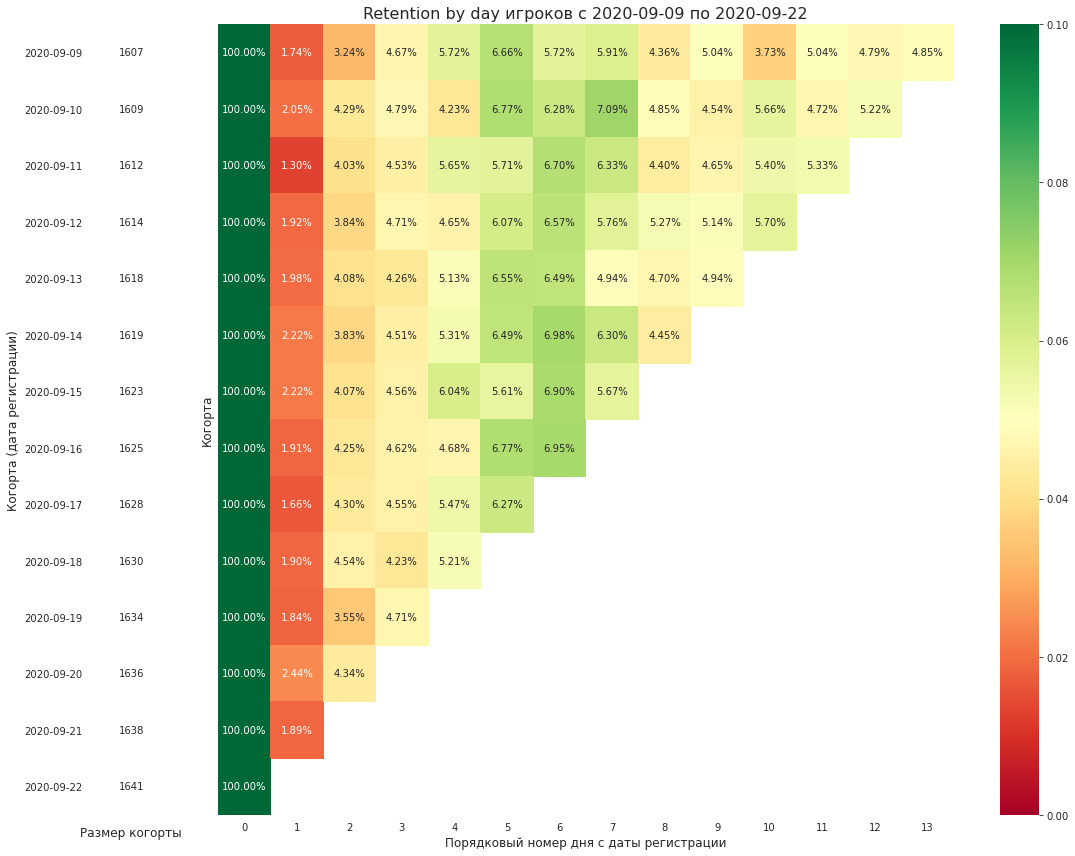

In [88]:
# Проверяем работу функции
reg_path = '/mnt/HC_Volume_18315164/home-jupyter/jupyter-nikolaj-sofinskij-pwt6989/shared/problem1-reg_data.csv'
auth_path = '/mnt/HC_Volume_18315164/home-jupyter/jupyter-nikolaj-sofinskij-pwt6989/shared/problem1-auth_data.csv'
start_date = '2020-09-09'
end_date = '2020-09-22'
calculate_retention(reg_path, auth_path, start_date, end_date)

Проанализируем удержание игроков (Retention Rate):

Для когортного анализа был выбран наиболее актуальный период в рамках имеющихся данных — последние две полные недели 
(с 9 по 22 сентября 2020 года).

Объем когорт: Ежедневный приток новых пользователей стабилен и находится в диапазоне от 1607 до 1641 игрока в день. 
Наблюдается легкий тренд на рост объема ежедневной привлекаемой аудитории к концу периода.

Динамика удержания: График демонстрирует специфическую динамику. Наиболее резкое падение активности происходит на 1-й день 
после регистрации (Retention 1 дня для когорт за указанный период составляет от 1.3% до 2.44%). На 5–7 дни наблюдается 
локальный пик удержания (от 4.94% до 7.09%), после чего показатель стабилизируется на уровне 4.5–5% для большинства когорт.

Продуктовый итог: Полученная динамика удержания достаточно нетипична: показатели возвращаемости первого дня минимальны, 
однако к концу первой недели активность пользователей в когортах заметно возрастает. Это может свидетельствовать о наличии 
сильных удерживающих механик, завязанных на еженедельный цикл (например, еженедельные внутриигровые события или крупные 
награды за вход), либо об отложенном онбординге. Данная особенность поведения аудитории требует дополнительного исследования 
со стороны продуктовой команды для оптимизации удержания на ранних этапах.

### Задание 2
Имеются результаты A/B теста, в котором двум группам пользователей предлагались различные наборы акционных предложений. Известно, что ARPU в тестовой группе выше на 5%, чем в контрольной. При этом в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667.

Какой набор предложений можно считать лучшим? Какие метрики стоит проанализировать для принятия правильного решения и как?

In [89]:
# Создаем датафрейм
ab_test_data = pd.read_csv('Проект_1_Задание_2.csv', sep=';')

Проведем предварительный анализ данных.

In [90]:
# Посмотрим на датафрейм ab_test_data
ab_test_data.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [91]:
# Узнаем количество строк и столбцов в датафрейме
print(f'ab_test_data:  {ab_test_data.shape}')

ab_test_data:  (404770, 3)


In [92]:
# Проверим типы данных в столбцах датафрейма
ab_test_data.dtypes

user_id       int64
revenue       int64
testgroup    object
dtype: object

In [93]:
# Проверим, есть ли в датафрейме пропущенные значения
ab_test_data.isna().sum()

user_id      0
revenue      0
testgroup    0
dtype: int64

In [94]:
# Проверим, как часто встречается каждое уникальное значение в столбце user_id
ab_test_data['user_id'].value_counts()

404770    1
1         1
404731    1
404732    1
404733    1
         ..
6         1
7         1
8         1
9         1
10        1
Name: user_id, Length: 404770, dtype: int64

In [95]:
# Посмотрим описательную статистику для колонки revenue
ab_test_data['revenue'].describe()

count    404770.000000
mean         26.083435
std         681.652928
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       37433.000000
Name: revenue, dtype: float64

In [96]:
# Посмотрим, корректно ли отражена группа в столбце testgroup
ab_test_data['testgroup'].unique()

array(['b', 'a'], dtype=object)

Посмотрим на данные по группам.

In [97]:
# Посмотрим на данные по группе a
ab_test_data.query('testgroup == "a"')

,user_id,revenue,testgroup
1,2,0,a
2,3,0,a
9,10,0,a
10,11,0,a
11,12,0,a
...,...,...,...
404760,404761,0,a
404762,404763,0,a
404765,404766,0,a
404767,404768,231,a


In [98]:
# Посмотрим на количество платящих пользователей из группы a
ab_test_data.query('testgroup == "a" and revenue > 0')

,user_id,revenue,testgroup
72,73,351,a
341,342,290,a
385,386,250,a
416,417,37324,a
712,713,255,a
...,...,...,...
404304,404305,360,a
404315,404316,262,a
404543,404544,369,a
404602,404603,251,a


In [99]:
# Посмотрим на данные по группе b
ab_test_data.query('testgroup == "b"')

,user_id,revenue,testgroup
0,1,0,b
3,4,0,b
4,5,0,b
5,6,0,b
6,7,0,b
...,...,...,...
404761,404762,0,b
404763,404764,0,b
404764,404765,0,b
404766,404767,0,b


In [100]:
# Посмотрим на количество платящих пользователей из группы b
ab_test_data.query('testgroup == "b" and revenue > 0')

,user_id,revenue,testgroup
160,161,3797,b
377,378,3768,b
386,387,3527,b
551,552,2038,b
913,914,3902,b
...,...,...,...
403843,403844,3383,b
403994,403995,2793,b
404161,404162,2316,b
404193,404194,2998,b


В датафрейме 404770 уникальных user_id, пропущенных значений нет.

Исходя из условия, группа "a" является контрольной, а группа "b" тестовой.

In [101]:
# Проверим, что ARPU в тестовой группе выше на 5%, чем в контрольной.
control_group_a_data = ab_test_data.query('testgroup == "a"')
arpu_control_group_a = control_group_a_data['revenue'].sum() / control_group_a_data['user_id'].nunique()
test_group_b_data = ab_test_data.query('testgroup == "b"')
arpu_test_group_b = test_group_b_data['revenue'].sum() / test_group_b_data['user_id'].nunique()
arpu_diff = ((arpu_test_group_b - arpu_control_group_a) / arpu_control_group_a) * 100
print(f'В тестовой группе ARPU выше на {round(arpu_diff, 2)}%')

В тестовой группе ARPU выше на 5.26%


Для определения лучшего набора акционных предложений необходимо проанализировать следующие метрики:
- ARPU: используем метод bootstrap (с 1000 подвыборок) для сравнения средних значений (построим 95% доверительный интервал
для разницы средних значений, используя процентильный метод)
- ARPPU: используем метод bootstrap (с 1000 подвыборок) для сравнения средних значений и медиан (построим 95% доверительные 
интервалы для разницы средних значений и разницы медиан, используя процентильный метод)
- Conversion Rate: используем критерий Хи-квадрат для сравнения двух долей (платящие/неплатящие)

Данные метрики связаны между собой: ARPU = ARPPU × CR

Сформулируем гипотезы для оценки каждой метрики:

1. Для ARPU:  
Для анализа средних значений:  
Нулевая гипотеза (H0): Средняя выручка на привлеченного пользователя в тестовой и контрольной группах одинакова.  
Альтернативная гипотеза (H1): Средняя выручка на привлеченного пользователя в группах статистически значимо различается.

2. Для ARPPU:  
Для анализа средних значений:  
Нулевая гипотеза (H0): Средняя выручка на одного платящего пользователя в группах совпадает.  
Альтернативная гипотеза (H1): Средняя выручка на одного платящего пользователя в группах статистически значимо различается.  
Для анализа медиан:  
Нулевая гипотеза (H0): Медианное значение выручки на одного платящего пользователя в группах совпадает.  
Альтернативная гипотеза (H1): Медианное значение выручки на одного платящего пользователя в группах статистически значимо 
различается.

3. Для Conversion Rate (CR):  
Для анализа конверсии:  
Нулевая гипотеза (H0): Между конверсией в контрольной группе и конверсией в тестовой группе нет статистически значимой разницы.
Альтернативная гипотеза (H1): Разница между конверсиями в группах статистически значима.

Для всех статистических тестов в рамках данного исследования установим стандартный уровень значимости α=0.05.

Начнем с анализа ARPU.

In [102]:
# Проверим, распределены ли данные нормально.
pg.normality(data=ab_test_data, dv="revenue", 
                   group="testgroup", method="normaltest")

,W,pval,normal
testgroup,,,
b,326622.395409,0.0,False
a,585152.731273,0.0,False


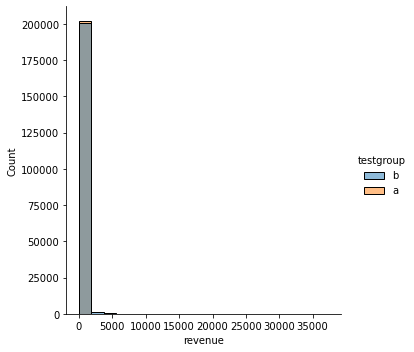

In [103]:
# Представим данные на графике
sns.displot(data=ab_test_data, x="revenue", hue="testgroup")

In [104]:
# Посмотрим на описательную статистику по группам
ab_test_data.groupby('testgroup')['revenue'].describe()

,count,mean,std,min,25%,50%,75%,max
testgroup,,,,,,,,
a,202103.0,25.413720,920.768137,0.0,0.0,0.0,0.0,37433.0
b,202667.0,26.751287,287.324162,0.0,0.0,0.0,0.0,4000.0


In [105]:
# Отдельно посмотрим на медианные значения (50-й процентиль)
all_median_a = ab_test_data.query('testgroup == "a"')['revenue'].median()
all_median_b = ab_test_data.query('testgroup == "b"')['revenue'].median()
print(f'Медианное значение в группе а: {all_median_a}')
print(f'Медианное значение в группе b: {all_median_b}')

Медианное значение в группе а: 0.0
Медианное значение в группе b: 0.0


In [106]:
# Посмотрим на 99, 99,5 и 99,9 процентили
# Рассчитываем процентили
percentiles = ab_test_data.groupby('testgroup')['revenue'].quantile([0.99, 0.995, 0.999])

# Разворачиваем мультииндекс и сразу сбрасываем его
percentiles_table = percentiles.unstack().reset_index()

# Переименовываем все колонки (первая теперь — это сброшенная группа)
percentiles_table.columns = ['Группа', '99-й процентиль', '99.5-й процентиль', '99.9-й процентиль']

# Округляем
percentiles_table = percentiles_table.round(2)

percentiles_table

,Группа,99-й процентиль,99.5-й процентиль,99.9-й процентиль
0,a,0.0,307.00,393.0
1,b,0.0,2890.67,3772.0


Распределение выручки в обеих группах кардинально отличается от нормального из-за выраженной специфики данных 
(около 99% пользователей не совершали покупок, а среди платящих присутствуют экстремальные выбросы-«киты»). 

По этой причине классический t-критерий Стьюдента может давать нестабильные результаты. 

Применение рангового критерия Манна-Уитни также нецелесообразно, так как он оценивает различие в распределении рангов
(различаются ли распределения), а не разность средних значений (ARPU), которую мы хотим оценить. Кроме того, обилие 
повторяющихся нулевых значений искажает ранжирование.

В связи с этим для проверки гипотез выберем метод Bootstrap.  
Бутстрап — это метод многократного извлечения подвыборок с возвращением из исходных данных. С его помощью мы можем симулировать распределение абсолютно любой метрики, включая разность средних (ARPU) и разность медиан (ARPPU), и построить для этой разности точный доверительный интервал.  
Метод не требует нормальности распределения исходных данных и отлично справляется с оценкой средних на таких специфических 
распределениях.

Для проверки гипотез о равенстве средних (ARPU, ARPPU) и медиан (ARPPU) вместо сравнения индивидуальных доверительных 
интервалов каждой группы был выбран метод построения доверительного интервала для разности показателей (разности средних 
или разности медиан).

Данный подход является более строгим и математически обоснованным по следующим причинам:  
Избежание ошибки "пересечения интервалов" (Overlap Fallacy):  
Сравнение пересечения двух независимых доверительных интервалов — это избыточно консервативный метод. В статистике доказано, 
что индивидуальные доверительные интервалы двух групп могут частично пересекаться, но при этом разность их средних значений
всё равно будет статистически значимой. Оценка перекрытия интервалов занижает мощность теста и увеличивает вероятность 
совершить ошибку II рода (не отклонить ложную нулевую гипотезу).  
Прямая оценка величины эффекта (Effect Size):  
Доверительный интервал для разности дает бизнесу точечную и интервальную оценку самого эффекта. Мы сразу видим не просто 
абстрактные границы значений в каждой группе, а конкретный диапазон того, насколько изменилась прибыль с одного пользователя 
при внедрении новых предложений.  
Прямая связь с проверяемой гипотезой:  
Поскольку нулевая гипотеза утверждает равенство показателей, построение доверительного интервала для разности напрямую 
отвечает на этот вопрос. Если интервал разности не включает 0, мы имеем строгое математическое основание отклонить нулевую 
гипотезу.

Для проведения бутстрап-анализа было выбрано количество подвыборок, равное 1000.  
Данный выбор обусловлен двумя ключевыми 
факторами:  
Статистическая точность: Согласно академическим стандартам и рекомендациям Брэдли Эфрона (создателя метода Bootstrap), 
для надежной оценки стандартной ошибки достаточно 50–200 репликаций, а для построения стабильного и точного 
95-го доверительного интервала (определения 2.5-го и 97.5-го процентилей) оптимальным является диапазон от 1000 
до 2000 подвыборок. Дальнейшее увеличение их числа (например, до 10 000) практически не влияет на ширину интервала и точность
выводов, но существенно увеличивает вычислительную нагрузку.  
Вычислительная производительность: Поскольку исходные выборки достаточно объемные (более 200 тысяч строк в каждой группе), 
генерация случайных подвыборок с возвращением требует времени. Использование 1000 итераций позволяет получить математически 
строгий результат за приемлемое время выполнения кода без зависания ядра Jupyter Notebook.

Для построения доверительных интервалов используется процентильный метод бутстрапа. Ввиду большого объема выборки (более 200 000 наблюдений в каждой группе) оценки средних и медиан в бутстрап-распределении достаточно стабильны, а возможные смещения минимальны, что делает процентильный метод репрезентативным и избавляет от необходимости усложнять вычисления методами коррекции смещения (например, BCa).

In [107]:
# Объявим функцию для расчета 95% доверительного интеравала для разницы показателей между группами при помощи метода bootstrap.
def conf_int_bootstrap(number_samples, control_group, test_group, stat):
    stat_diff = []
    for i in range(number_samples):
        sample_data_control = control_group.sample(frac=1, replace=True)
        sample_stat_control = stat(sample_data_control)
    
    
        sample_data_test = test_group.sample(frac=1, replace=True)
        sample_stat_test = stat(sample_data_test)
    
        sample_stat_diff = sample_stat_test - sample_stat_control
        stat_diff.append(sample_stat_diff)
    low_conf_lev = pd.Series(stat_diff).quantile(0.025).round(2)
    high_conf_lev = pd.Series(stat_diff).quantile(0.975).round(2)
    return low_conf_lev, high_conf_lev, stat_diff

Проверим гипотезу для ARPU:  
Для анализа средних значений:  
Нулевая гипотеза (H0): Средняя выручка на привлеченного пользователя в тестовой и контрольной группах одинакова.  
Альтернативная гипотеза (H1): Средняя выручка на привлеченного пользователя в группах статистически значимо различается.

In [108]:
# Рассчитаем 95% доверительный интервал для разницы среднего значения
number_samples = 1000
control_group = ab_test_data.query('testgroup == "a"')['revenue']
test_group = ab_test_data.query('testgroup == "b"')['revenue']
stat = np.mean
low, high, diffs = conf_int_bootstrap(number_samples, control_group, test_group, stat)
print(f'Доверительный интервал [{low} ; {high}]')

Доверительный интервал [-3.19 ; 5.5]


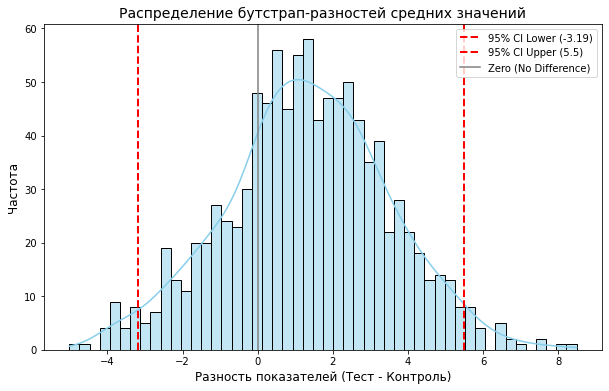

In [109]:
# Построим график распределения разностей
plt.figure(figsize=(10, 6))
sns.histplot(diffs, kde=True, bins=50, color='skyblue')

# Добавляем вертикальные линии для границ доверительного интервала
plt.axvline(x=low, color='red', linestyle='--', linewidth=2, label=f'95% CI Lower ({low})')
plt.axvline(x=high, color='red', linestyle='--', linewidth=2, label=f'95% CI Upper ({high})')

# Добавляем линию нуля, чтобы наглядно показать, входит ли он в интервал
plt.axvline(x=0, color='grey', linestyle='-', linewidth=1.5, label='Zero (No Difference)')

# Оформляем график
plt.title('Распределение бутстрап-разностей средних значений', fontsize=14)
plt.xlabel('Разность показателей (Тест - Контроль)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.legend(loc='upper right')
plt.show()

Доверительный интервал включает 0, это означает, что у нас нет оснований отклонить нулевую гипотезу (H0):
Средняя выручка на привлеченного пользователя в тестовой и контрольной группах одинакова.
Это связано с экстремально высокой дисперсией в контрольной группе (а), вызванной присутствием "китов" с аномально 
крупными чеками. В итоге данные выбросы завышают среднее значение в контрольной группе.

Перейдем к анализу ARPPU.

In [110]:
# Проверим, распределены ли данные нормально.
pg.normality(data=ab_test_data.query('revenue  > 0'), dv="revenue", 
                   group="testgroup", method="normaltest")

,W,pval,normal
testgroup,,,
a,1394.945784,1.234161e-303,False
b,1068.860008,7.943249e-233,False


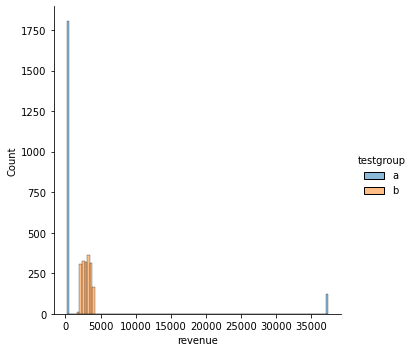

In [111]:
# Представим данные на графике
sns.displot(data=ab_test_data.query('revenue  > 0'), x="revenue", hue="testgroup")

In [112]:
# Посмотрим на описательную статистику по группам
ab_test_data.query('revenue > 0').groupby('testgroup')['revenue'].describe()

,count,mean,std,min,25%,50%,75%,max
testgroup,,,,,,,,
a,1928.0,2663.998444,9049.039763,200.0,257.0,311.0,361.0,37433.0
b,1805.0,3003.658172,572.619709,2000.0,2513.0,3022.0,3478.0,4000.0


In [113]:
# Отдельно посмотрим на медианные значения (50-й процентиль)
median_a = ab_test_data.query('revenue > 0 and testgroup == "a"')['revenue'].median()
median_b = ab_test_data.query('revenue > 0 and testgroup == "b"')['revenue'].median()
print(f'Медианное значение в группе а:  {median_a}')
print(f'Медианное значение в группе b: {median_b}')

Медианное значение в группе а:  311.0
Медианное значение в группе b: 3022.0


In [114]:
# Посмотрим на 92, 93, 94 и 95 процентили
# Рассчитываем процентили
percentiles_pay = ab_test_data.query('revenue > 0').groupby('testgroup')['revenue'].quantile([0.92, 0.93, 0.94, 0.95])

# Разворачиваем мультииндекс и сразу сбрасываем его
percentiles_pay_table = percentiles_pay.unstack().reset_index()

# Переименовываем все колонки (первая теперь — это сброшенная группа)
percentiles_pay_table.columns = ['Группа', '92-й процентиль', '93-й процентиль', '94-й процентиль', '95-й процентиль']

# Округляем
percentiles_pay_table = percentiles_pay_table.round(2)

percentiles_pay_table

,Группа,92-й процентиль,93-й процентиль,94-й процентиль,95-й процентиль
0,a,397.00,399.0,37295.0,37299.65
1,b,3832.68,3855.0,3872.0,3891.80


Распределение выручки в обеих группах кардинально отличается от нормального из-за выраженной специфики данных (среди платящих
присутствуют экстремальные выбросы-«киты»).

По этой причине классический t-критерий Стьюдента может давать нестабильные результаты. 

Применение рангового критерия Манна-Уитни также нецелесообразно, так как он оценивает различие в распределении рангов
(различаются ли распределения), а не разность средних значений и медиан, которую мы хотим оценить.
Также он не позволяет получить количественную оценку разности медиан и построить для неё доверительный интервал. 

Бизнесу всегда важно знать не просто факт наличия различий, а то, на какую конкретно сумму различаются типичные платежи 
клиентов.  
В связи с этим для проверки гипотез выберем метод Bootstrap.

Проверим первую гипотезу для ARPPU:  
Для анализа средних значений:  
Нулевая гипотеза (H0): Средняя выручка на одного платящего пользователя в группах совпадает.  
Альтернативная гипотеза (H1): Средняя выручка на одного платящего пользователя в группах статистически значимо различается.

In [115]:
# Рассчитаем 95% доверительный интервал для разницы среднего значения
number_samples = 1000
control_group = ab_test_data.query('revenue > 0 and testgroup == "a"')['revenue']
test_group = ab_test_data.query('revenue > 0 and testgroup == "b"')['revenue']
stat = np.mean
low, high, diffs = conf_int_bootstrap(number_samples, control_group, test_group, stat)
print(f'Доверительный интервал [{low} ; {high}]')

Доверительный интервал [-66.71 ; 729.28]


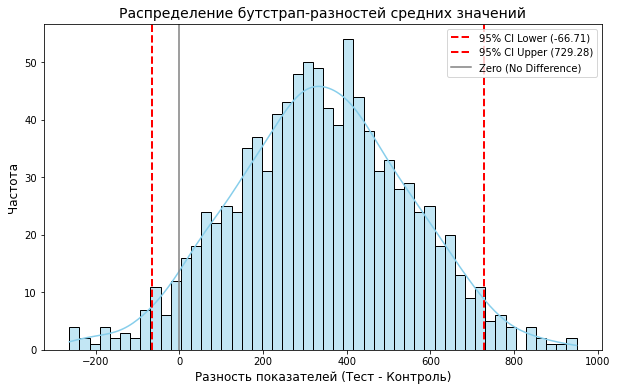

In [116]:
# Построим график распределения разностей
plt.figure(figsize=(10, 6))
sns.histplot(diffs, kde=True, bins=50, color='skyblue')

# Добавляем вертикальные линии для границ доверительного интервала
plt.axvline(x=low, color='red', linestyle='--', linewidth=2, label=f'95% CI Lower ({low})')
plt.axvline(x=high, color='red', linestyle='--', linewidth=2, label=f'95% CI Upper ({high})')

# Добавляем линию нуля, чтобы наглядно показать, входит ли он в интервал
plt.axvline(x=0, color='grey', linestyle='-', linewidth=1.5, label='Zero (No Difference)')

# Оформляем график
plt.title('Распределение бутстрап-разностей средних значений', fontsize=14)
plt.xlabel('Разность показателей (Тест - Контроль)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.legend(loc='upper right')
plt.show()

Доверительный интервал включает 0, это означает, что у нас нет оснований отклонить нулевую гипотезу (H0): Средняя выручка 
на одного платящего пользователя в группах совпадает.  
Это связано с экстремально высокой дисперсией в контрольной группе (а), вызванной присутствием "китов" с аномально 
крупными чеками. Данные выбросы сильно увеличили среднее значение. Огромный разброс данных делает доверительный интервал для разности средних слишком широким, из-за чего он включает ноль.

Поскольку среднее арифметическое слишком чувствительно к выбросам, для оценки поведения "типичного" платящего игрока 
мы применим bootstrap для сравнения медиан.

Проверим вторую гипотезу для ARPPU:  
Для анализа медиан:  
Нулевая гипотеза (H0): Медианное значение выручки на одного платящего пользователя в группах совпадает.  
Альтернативная гипотеза (H1): Медианное значение выручки на одного платящего пользователя в группах статистически значимо 
различается.

In [117]:
# Рассчитаем 95% доверительный интервал для разницы медиан
number_samples = 1000
control_group = ab_test_data.query('revenue > 0 and testgroup == "a"')['revenue']
test_group = ab_test_data.query('revenue > 0 and testgroup == "b"')['revenue']
stat = np.median
low, high, diffs = conf_int_bootstrap(number_samples, control_group, test_group, stat)
print(f'Доверительный интервал [{low} ; {high}]')

Доверительный интервал [2660.49 ; 2761.0]


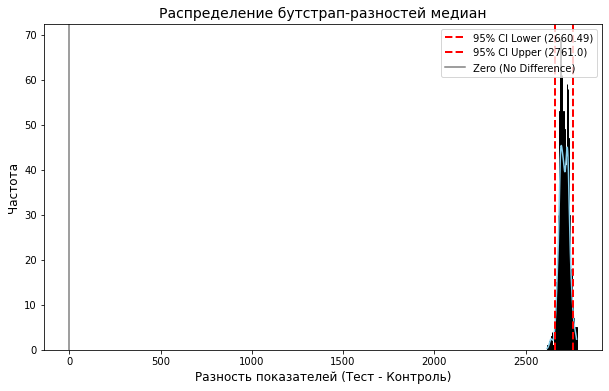

In [118]:
# Построим график распределения разностей
plt.figure(figsize=(10, 6))
sns.histplot(diffs, kde=True, bins=50, color='skyblue')

# Добавляем вертикальные линии для границ доверительного интервала
plt.axvline(x=low, color='red', linestyle='--', linewidth=2, label=f'95% CI Lower ({low})')
plt.axvline(x=high, color='red', linestyle='--', linewidth=2, label=f'95% CI Upper ({high})')

# Добавляем линию нуля, чтобы наглядно показать, входит ли он в интервал
plt.axvline(x=0, color='grey', linestyle='-', linewidth=1.5, label='Zero (No Difference)')

# Оформляем график
plt.title('Распределение бутстрап-разностей медиан', fontsize=14)
plt.xlabel('Разность показателей (Тест - Контроль)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.legend(loc='upper right')
plt.show()

Доверительный интервал не включает 0, это означает, что мы отклоняем нулевую гипотезу (H0):
Медианное значение выручки на одного платящего пользователя в группах совпадает.  
Мы принимаем альтернативную гипотезу (H1): Медианное значение выручки на одного платящего пользователя в группах 
статистически значимо различается.  
Медианный чек платящего пользователя в тестовой группе оказался статистически значимо выше (примерно в 10 раз).

Перейдем к анализу Conversion Rate (CR):

Для анализа конверсии:  
Нулевая гипотеза (H0): Между конверсией в контрольной группе и конверсией в тестовой группе нет статистически значимой разницы.  Альтернативная гипотеза (H1): Разница между конверсиями в группах статистически значима.

Для оценки статистической значимости различий в конверсии (Conversion Rate) между контрольной и тестовой группами выберем
критерий Хи-квадрат Пирсона.  
Этот выбор обусловлен следующими факторами:  
1. Тип данных — целевая метрика (конверсия) является качественным (номинальным, бинарным) показателем: пользователь либо 
перешел в категорию платящих, либо остался неплатящим.  
2. Дизайн эксперимента — мы сравниваем доли в двух независимых группах пользователей (контрольной и тестовой).  
3. Размер выборки — объемы данных в группах составляют более 200 тысяч пользователей, а абсолютные частоты в ячейках таблицы 
сопряженности значительно превышают минимальное требование в 5–10 наблюдений, что гарантирует высокую точность и применимость
критерия.

In [119]:
# Посчитаем конверсию в контрольной и тестовой группах.
conversion_table = ab_test_data.groupby('testgroup', as_index=False).agg(
    total_users=('user_id', 'count'),
    paying_users=('revenue', lambda x: (x > 0).sum())
)
conversion_table['non_paying_users'] = conversion_table['total_users'] - conversion_table['paying_users']
conversion_table['cr_percent'] = (conversion_table['paying_users'] / conversion_table['total_users']) * 100
conversion_table

,testgroup,total_users,paying_users,non_paying_users,cr_percent
0,a,202103,1928,200175,0.953969
1,b,202667,1805,200862,0.890624


In [120]:
# Создадим таблицу сопряженности
contingency_table = [
    [conversion_table.loc[0, 'paying_users'], conversion_table.loc[0, 'non_paying_users']], # Группа A
    [conversion_table.loc[1, 'paying_users'], conversion_table.loc[1, 'non_paying_users']]  # Группа B
]
contingency_table

[[1928, 200175], [1805, 200862]]

In [121]:
# Применяем критерий Хи-квадрат и смотрим на p-value
chi2, p_val, dof, expected = st.chi2_contingency(contingency_table)
print(f'p-value: {p_val}')

p-value: 0.03647561892312613


p-value меньше порога значимости α=0.05, поэтому мы отклоняем нулевую гипотезу (H0):
Между конверсией в контрольной группе и конверсией в тестовой группе нет статистически значимой разницы
и принммаем альтернативную гипотезу (H1): Разница между конверсиями в группах статистически значима.
Конверсия статистически значимо снизилась с 0,95% до 0,89%.

Подведем итоги:
1. ARPU (на всех пользователей): Статистически значимых различий в средних значениях не обнаружено, что обусловлено 
колоссальной дисперсией в контрольной группе.
2. ARPPU (на платящих): 
- Средняя выручка на одного платящего пользователя в группах совпадает (статистически значимо не различается).
Это связано с экстремально высокой дисперсией в контрольной группе (а), вызванной присутствием "китов" с аномально 
крупными чеками. В итоге данные выбросы завышают среднее значение в контрольной группе.
- Медианное значение выручки на одного платящего пользователя в тестовой группе статистически значимо и кардинально выросло 
(приблизительно в 10 раз). В контрольной группе выручка держится на редких «китах» со сверхвысокими чеками, в то время 
как в тестовой группе платежи распределены более равномерно и стабильно.
3. Conversion Rate (конверсия): Статистически значимо снизилась в тестовой группе (примерно на 0.06 процентного пункта).

Сформулируем вывод:  
На основе проведенного анализа лучшим стоит признать набор предложений тестовой группы (вариант b). Несмотря на статистически
значимое снижение конверсии на 0.06 процентного пункта, данный вариант обладает рядом важнейших преимуществ для бизнеса:
1. Стабильность и прогнозируемость выручки: В контрольной группе (вариант a) выручка критически зависит от очень маленькой группы сверхплатящих пользователей ("китов"). Если эти пользователи покинут проект, выручка резко упадет. 
В тестовой группе (вариант b) мы наблюдаем равномерное распределение платежей среди платящей аудитории, что делает доходы 
компании более предсказуемыми.
2. Существенный рост ценности платящего пользователя: Медианный чек платящего игрока вырос в 10 раз, что полностью 
компенсирует незначительную потерю в конверсии и в долгосрочной перспективе позволяет гораздо эффективнее окупать затраты 
на привлечение новых пользователей.
3. Потенциал для масштабирования: Схема монетизации, ориентированная на более широкий пласт платящих игроков с высоким 
средним чеком, гораздо лучше поддается масштабированию и оптимизации, чем попытки удержать единичных "китов".

Рекомендация: Раскатить набор предложений тестовой группы (вариант b) на всех пользователей. Дополнительно продуктовой 
команде рекомендуется исследовать причины снижения конверсии на 0.06 п.п., чтобы доработать подачу акций и минимизировать 
этот отток в будущем.

### Задание 3
В игре Plants & Gardens каждый месяц проводятся тематические события, ограниченные по времени. В них игроки могут получить уникальные предметы для сада и персонажей, дополнительные монеты или бонусы. Для получения награды требуется пройти ряд уровней за определенное время. С помощью каких метрик можно оценить результаты последнего прошедшего события?

Предположим, в другом событии мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад. Изменится ли набор метрик оценки результата? Если да, то как?

Ответим на первую часть - "С помощью каких метрик можно оценить результаты последнего прошедшего события?"

Разделим метрики на два уровня:

1. Уровень фичи (микро-уровень): Оцениваем качество самого события. Оценим метрики вовлечения в событие, воронку прохождения 
уровней и траты внутри события.
- Количество игроков, принявших участие в событии
- Доля игроков, которые приняли участие в событии от общего числа активных игроков за период проведения события
- Среднее время участие игрока в событии
- Доля завершивших событие: отношение игроков, прошедших все уровни и забравших награду, к числу тех, кто начал участие
- Воронка прохождения уровней: шагами воронки выступают уровни события. Она наглядно подсветит «узкие места» — уровни, 
на которых игроки чаще всего застревают и бросают играть.
- Среднее количество попыток на уровень: позволяет оценить сложность каждого конкретного уровня.
- ARPU, ARPPU и Conversion Rate игроков, принявших участие в событии.

2. Уровень продукта (макро-уровень): Оцениваем влияние события на игру в целом. Cравнивним глобальные метрики проекта 
(DAU, ARPU, среднее время в приложении) «сезонного» периода (во время события) с «базовым» периодом (вне события).
- DAU - количество уникальных пользователей, которые совершили какое-либо действие в игре за сутки.
- MAU - количество уникальных пользователей, которые совершили хотя бы одно активное действие в игре за месяц.
- Среднее время проведения активного игрока в игре в сутки
- Среднее время проведения активного игрока в игре в месяц
- ARPU, ARPPU и Conversion Rate всех игроков
- Retention Rate: дневной и месячный


Ответим на вторую часть - "Изменится ли набор метрик оценки результата? Если да, то как?"

Набор метрик определенно изменится и расширится, так как стандартных продуктовых метрик станет недостаточно для оценки 
специфического поведения пользователей.
1. Изменение метрик прохождения уровней (разрушение линейной воронки).
При обычной механике игрок идет строго вперед. При механике отката у нас появляются «петли» — один и тот же уровень 
игрок проходит многократно не просто из-за обычного проигрыша, а потому что его туда "отбросило" с верхних уровней.
- Коэффициент повторного прохождения: отношение общего количества попыток на уровне к числу уникальных 
игроков, дошедших до него. Рост этой метрики покажет, на каких уровнях игроки "застревают" в циклах откатов.
- Среднее число откатов на пользователя: сколько раз в среднем один игрок падал назад. Важно смотреть не только на среднее, 
но и на максимальные значения (например, 95-й процентиль), чтобы выявить игроков, попавших в "бесконечный цикл" неудач.
2. Метрики недовольства.
Слишком сильное наказание за ошибку может вызвать негатив, из-за чего игроки просто бросят событие или вовсе удалят игру.
- Отток после отката: доля игроков, которые полностью прекратили играть в событие в течение суток после того, как у них 
случился откат.
- Доля выходов на эмоциях: процент игровых сессий, которые завершились закрытием приложения непосредственно 
на экране поражения с откатом или в течение нескольких секунд после него.
3. Изменение монетизации (триггер «страха потери»).
Страх потерять накопленный прогресс и откатиться назад — сильнейший психологический стимул к покупке.
- Конверсия в покупку на экране поражения: доля игроков, приобретающих дополнительные ходы, жизни или специальные бустеры 
"защиты от отката" именно в момент угрозы падения на предыдущие уровни.
- Доля выручки от бустеров сохранения: если в событии продаются специальные предметы, временно защищающие от отката, нужно 
отслеживать их продажи отдельно.
4. Влияние на глобальные метрики.
Нужно отслеживать, не вредит ли эта механика всей игре:
- Retention Rate 1-го и 3-го дня после старта события: если удержание падает сильнее обычного, механика слишком репрессивна 
и вредит лояльности аудитории.